Shape: (100000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         100000 non-null  object 
 1   REGION          60844 non-null   object 
 2   TENURE          100000 non-null  object 
 3   MONTANT         65059 non-null   float64
 4   FREQUENCE_RECH  65059 non-null   float64
 5   REVENUE         66484 non-null   float64
 6   ARPU_SEGMENT    66484 non-null   float64
 7   FREQUENCE       66484 non-null   float64
 8   DATA_VOLUME     50813 non-null   float64
 9   ON_NET          63663 non-null   float64
 10  ORANGE          58621 non-null   float64
 11  TIGO            40369 non-null   float64
 12  ZONE1           7909 non-null    float64
 13  ZONE2           6493 non-null    float64
 14  MRG             100000 non-null  object 
 15  REGULARITY      100000 non-null  int64  
 16  TOP_PACK        58264 non-null   obje

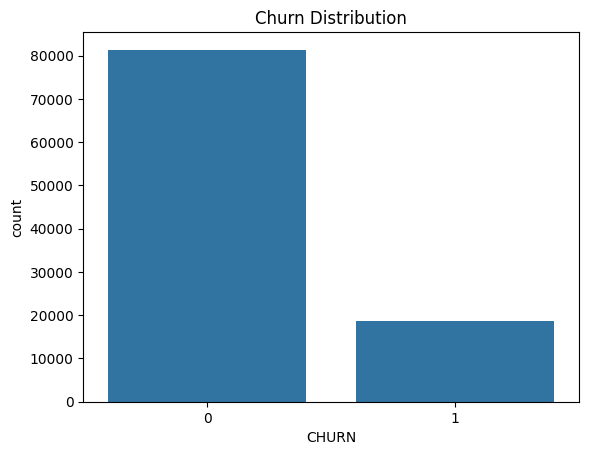

CHURN
0    81345
1    18655
Name: count, dtype: int64


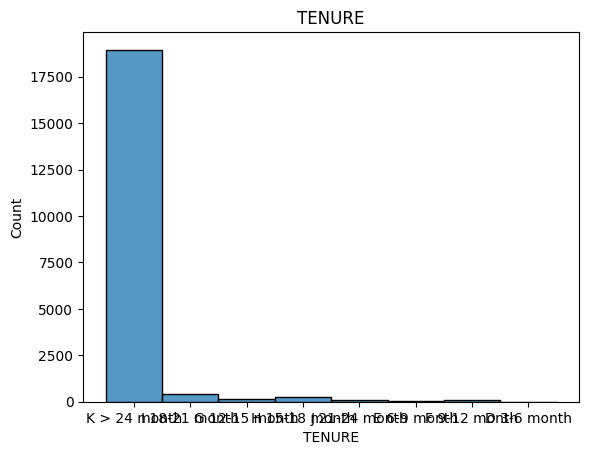

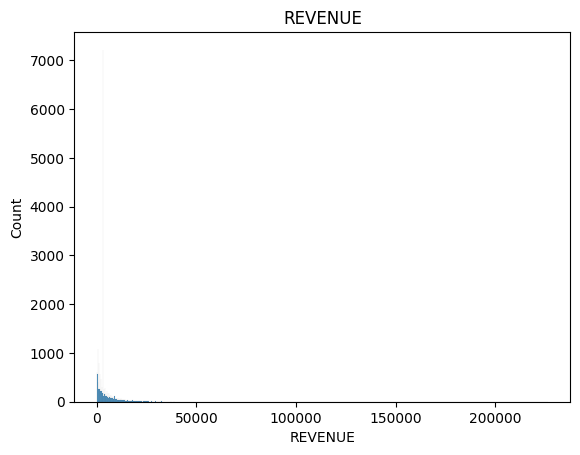

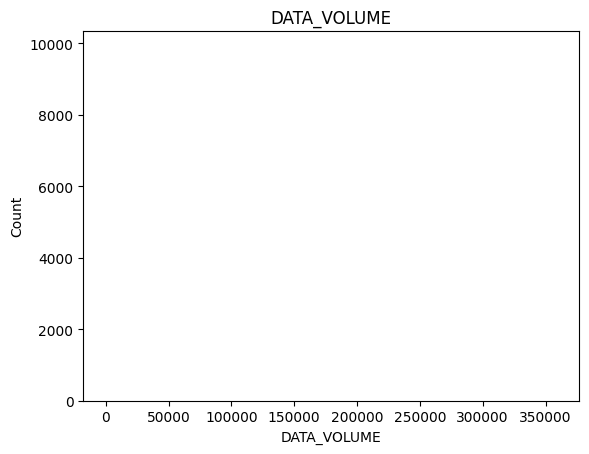

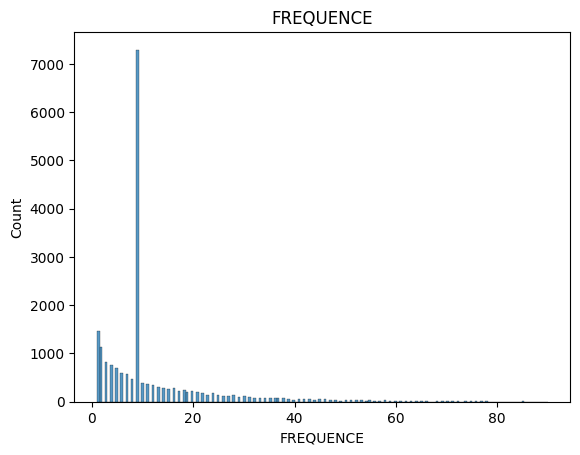

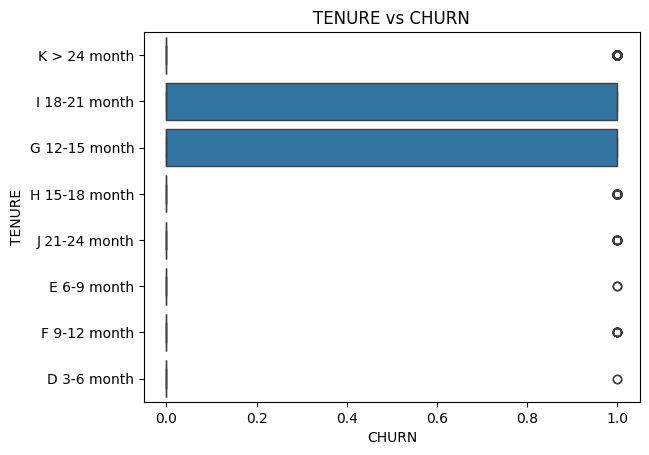

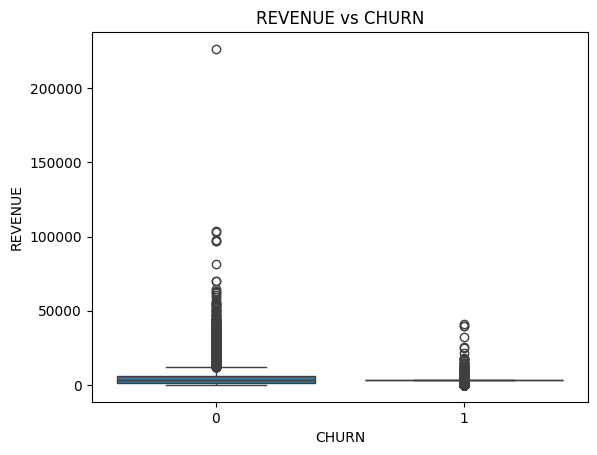

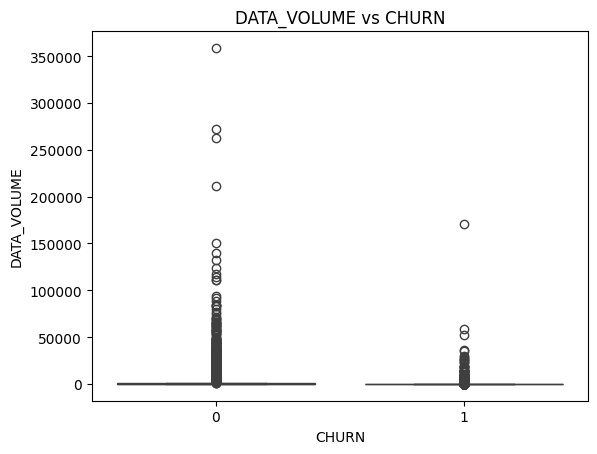

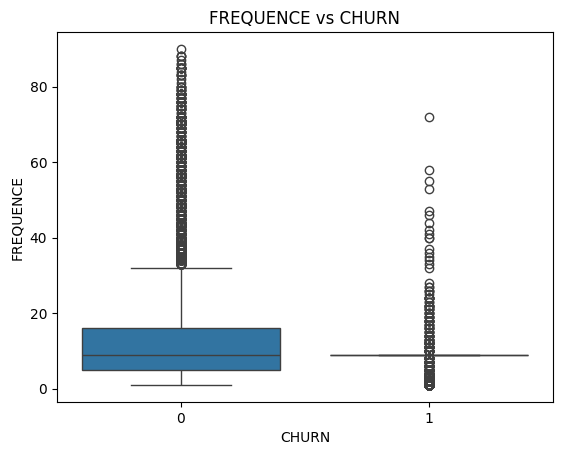

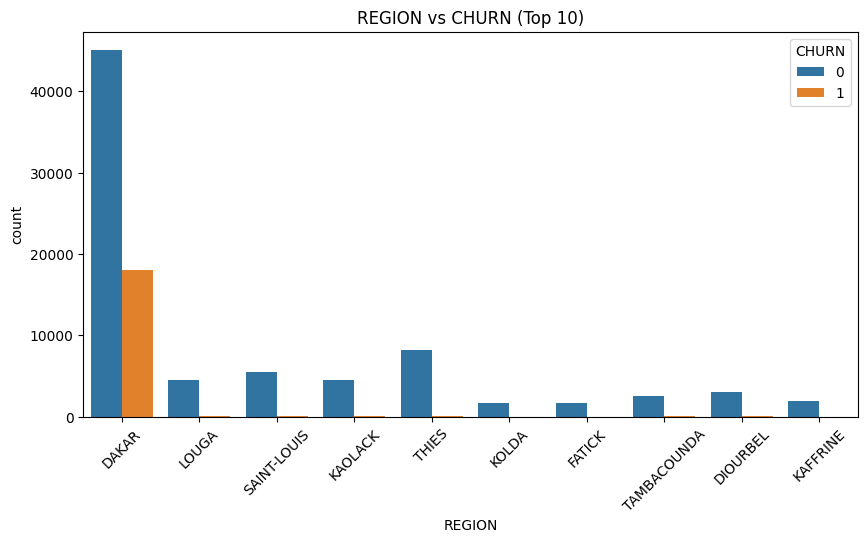

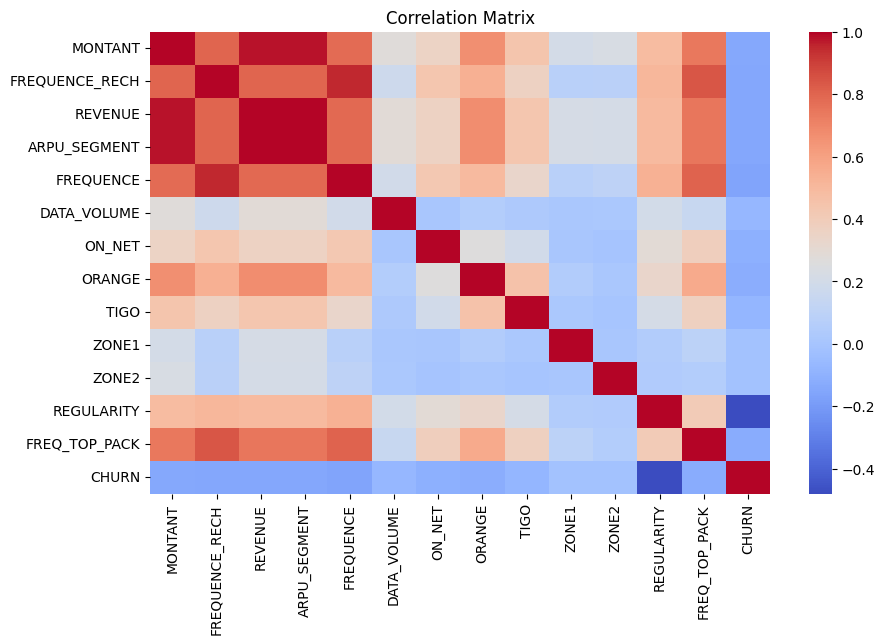


Key Insights:
- Low tenure customers are more likely to churn.
- Lower revenue correlates with churn.
- Low usage (frequency + data) increases churn.
- Some regions show higher churn.
- Active users are less likely to leave.



In [1]:
# =========================
# 1. Import Libraries
# =========================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 2. Load Dataset
# =========================
url = "https://drive.google.com/uc?id=1Bv0q9pV0sOLHQlS7x7OaACvdEHPLRcHM"
df = pd.read_csv(url)

# =========================
# 3. Data Overview
# =========================
print("Shape:", df.shape)
print(df.info())

# =========================
# 4. Data Cleaning (FAST VERSION)
# =========================

# Clean column names
df.columns = df.columns.str.strip()

# Identify columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('CHURN')

cat_cols = df.select_dtypes(include='object').columns.tolist()

# Fill missing values (FAST - NO LOOPS)
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df[cat_cols] = df[cat_cols].fillna(
    df[cat_cols].mode().iloc[0]
)

print("\nMissing after cleaning:\n", df.isnull().sum())
print("\nShape after cleaning:", df.shape)

# =========================
# 5. Target Analysis
# =========================
sns.countplot(x='CHURN', data=df)
plt.title("Churn Distribution")
plt.show()

print(df['CHURN'].value_counts())

# =========================
# 6. Faster Sampling for Plots
# =========================
sample_df = df.sample(20000, random_state=42)

num_features = ['TENURE', 'REVENUE', 'DATA_VOLUME', 'FREQUENCE']

for col in num_features:
    plt.figure()
    sns.histplot(sample_df[col], kde=False)
    plt.title(col)
    plt.show()

# =========================
# 7. Bivariate Analysis
# =========================
for col in ['TENURE', 'REVENUE', 'DATA_VOLUME', 'FREQUENCE']:
    plt.figure()
    sns.boxplot(x='CHURN', y=col, data=sample_df)
    plt.title(f"{col} vs CHURN")
    plt.show()

# REGION (Top 10 only)
top_regions = df['REGION'].value_counts().nlargest(10).index

plt.figure(figsize=(10,5))
sns.countplot(
    data=df[df['REGION'].isin(top_regions)],
    x='REGION',
    hue='CHURN'
)
plt.xticks(rotation=45)
plt.title("REGION vs CHURN (Top 10)")
plt.show()

# =========================
# 8. Correlation
# =========================
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# =========================
# 9. Feature Engineering
# =========================
df['ActivityScore'] = df['FREQUENCE'] + df['DATA_VOLUME']

# =========================
# 10. Insights
# =========================
print("""
Key Insights:
- Low tenure customers are more likely to churn.
- Lower revenue correlates with churn.
- Low usage (frequency + data) increases churn.
- Some regions show higher churn.
- Active users are less likely to leave.
""")